# Analyze RL Trajectories

Load trajectories saved by `rl/experiments/compare_pretrained_rl_atoms.py`, summarize them, and visualize final molecules sorted by decreasing atom count.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repository root (missing pyproject.toml in parents)")


PROJECT_ROOT = find_repo_root(Path.cwd())
for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"PROJECT_ROOT={PROJECT_ROOT}")

PROJECT_ROOT=/network/scratch/g/goldszaa/chemflow


In [ ]:
# Adjust this path if you saved trajectories elsewhere.
TRAJ_PATH = PROJECT_ROOT / "rl" / "experiments" / "natoms" / "grpo_natoms_seed0_sig0p05_g1_mu2_kl0.02_lr1e-4_maxa60_omitposkl_scaff_b10_p0p5_w100_canonsmi_best" / "rl_valid_trajectories.pt"

if not TRAJ_PATH.exists():
    raise FileNotFoundError(
        f"Trajectory file not found at {TRAJ_PATH}. "
        "Run compare_pretrained_rl_atoms.py first, or update TRAJ_PATH."
    )

blob = torch.load(str(TRAJ_PATH), weights_only=False)
records = blob.get("records", [])

print(f"Loaded: {TRAJ_PATH}")
print(f"Saved records: {len(records)}")

/home/mila/g/goldszaa/scratch/chemflow/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: /network/scratch/g/goldszaa/chemflow/rl/experiments/natoms/grpo_natoms_seed0_sig0p05_g1_mu2_kl0.02_lr1e-4_maxa60_omitposkl_scaff_b10_p0p5_w50_canonsmi_best/rl_valid_trajectories.pt
Saved records: 294


In [3]:
import time

_t0 = time.perf_counter()
print("Cell 3: starting atom-count summary...")

if records is None:
    records = []

if not isinstance(records, list):
    print(f"records is {type(records).__name__}; materializing to a list now...")
    records = list(records)

print(f"records type={type(records).__name__}, n={len(records)}")

if not records:
    print("No records found.")
else:
    atom_values = []
    for i, r in enumerate(records):
        try:
            atom_values.append(int(r["final_n_atoms"]))
        except Exception as exc:
            keys = list(r.keys()) if isinstance(r, dict) else None
            print(f"Failed to parse record {i}: type={type(r).__name__}, keys={keys}")
            raise RuntimeError(f"Bad record at index {i}") from exc

    atom_counts = np.array(atom_values, dtype=int)
    counter = Counter(atom_counts.tolist())

    print("=== Metadata ===")
    print("rl_ckpt:", blob.get("rl_ckpt"))
    print("pretrained_ckpt:", blob.get("pretrained_ckpt"))
    print("n_mols_requested:", blob.get("n_mols_requested"))
    print("min_atoms:", blob.get("min_atoms"))
    print("rl_validity:", blob.get("rl_validity"))

    print("\n=== Atom-count stats over saved records ===")
    print("count:", int(atom_counts.size))
    print("mean:", float(atom_counts.mean()))
    print("median:", float(np.median(atom_counts)))
    print("min:", int(atom_counts.min()))
    print("max:", int(atom_counts.max()))

    print("\n=== Frequency (top 15 atom counts) ===")
    for n_atoms, freq in sorted(counter.items(), key=lambda kv: (-kv[1], -kv[0]))[:15]:
        print(f"n_atoms={n_atoms:>3} -> {freq}")

print(f"Cell 3: done in {time.perf_counter() - _t0:.3f}s")

Cell 3: starting atom-count summary...
records type=list, n=294
=== Metadata ===
rl_ckpt: /network/scratch/g/goldszaa/chemflow/.rl_ckpts/grpo_natoms_seed0_sig0p05_g1_mu2_kl0.02_lr1e-4_maxa60_omitposkl_scaff_b10_p0p5_w50_canonsmi_best.pt
pretrained_ckpt: /network/scratch/g/goldszaa/chemflow/.pretrained_model/epoch=499-step=48500.ckpt
n_mols_requested: 300
min_atoms: 32
rl_validity: 0.9833333333333333

=== Atom-count stats over saved records ===
count: 294
mean: 36.074829931972786
median: 36.0
min: 32
max: 40

=== Frequency (top 15 atom counts) ===
n_atoms= 37 -> 82
n_atoms= 34 -> 64
n_atoms= 35 -> 46
n_atoms= 39 -> 36
n_atoms= 36 -> 28
n_atoms= 40 -> 14
n_atoms= 32 -> 13
n_atoms= 38 -> 7
n_atoms= 33 -> 4
Cell 3: done in 0.004s


/home/mila/g/goldszaa/scratch/chemflow/.venv/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


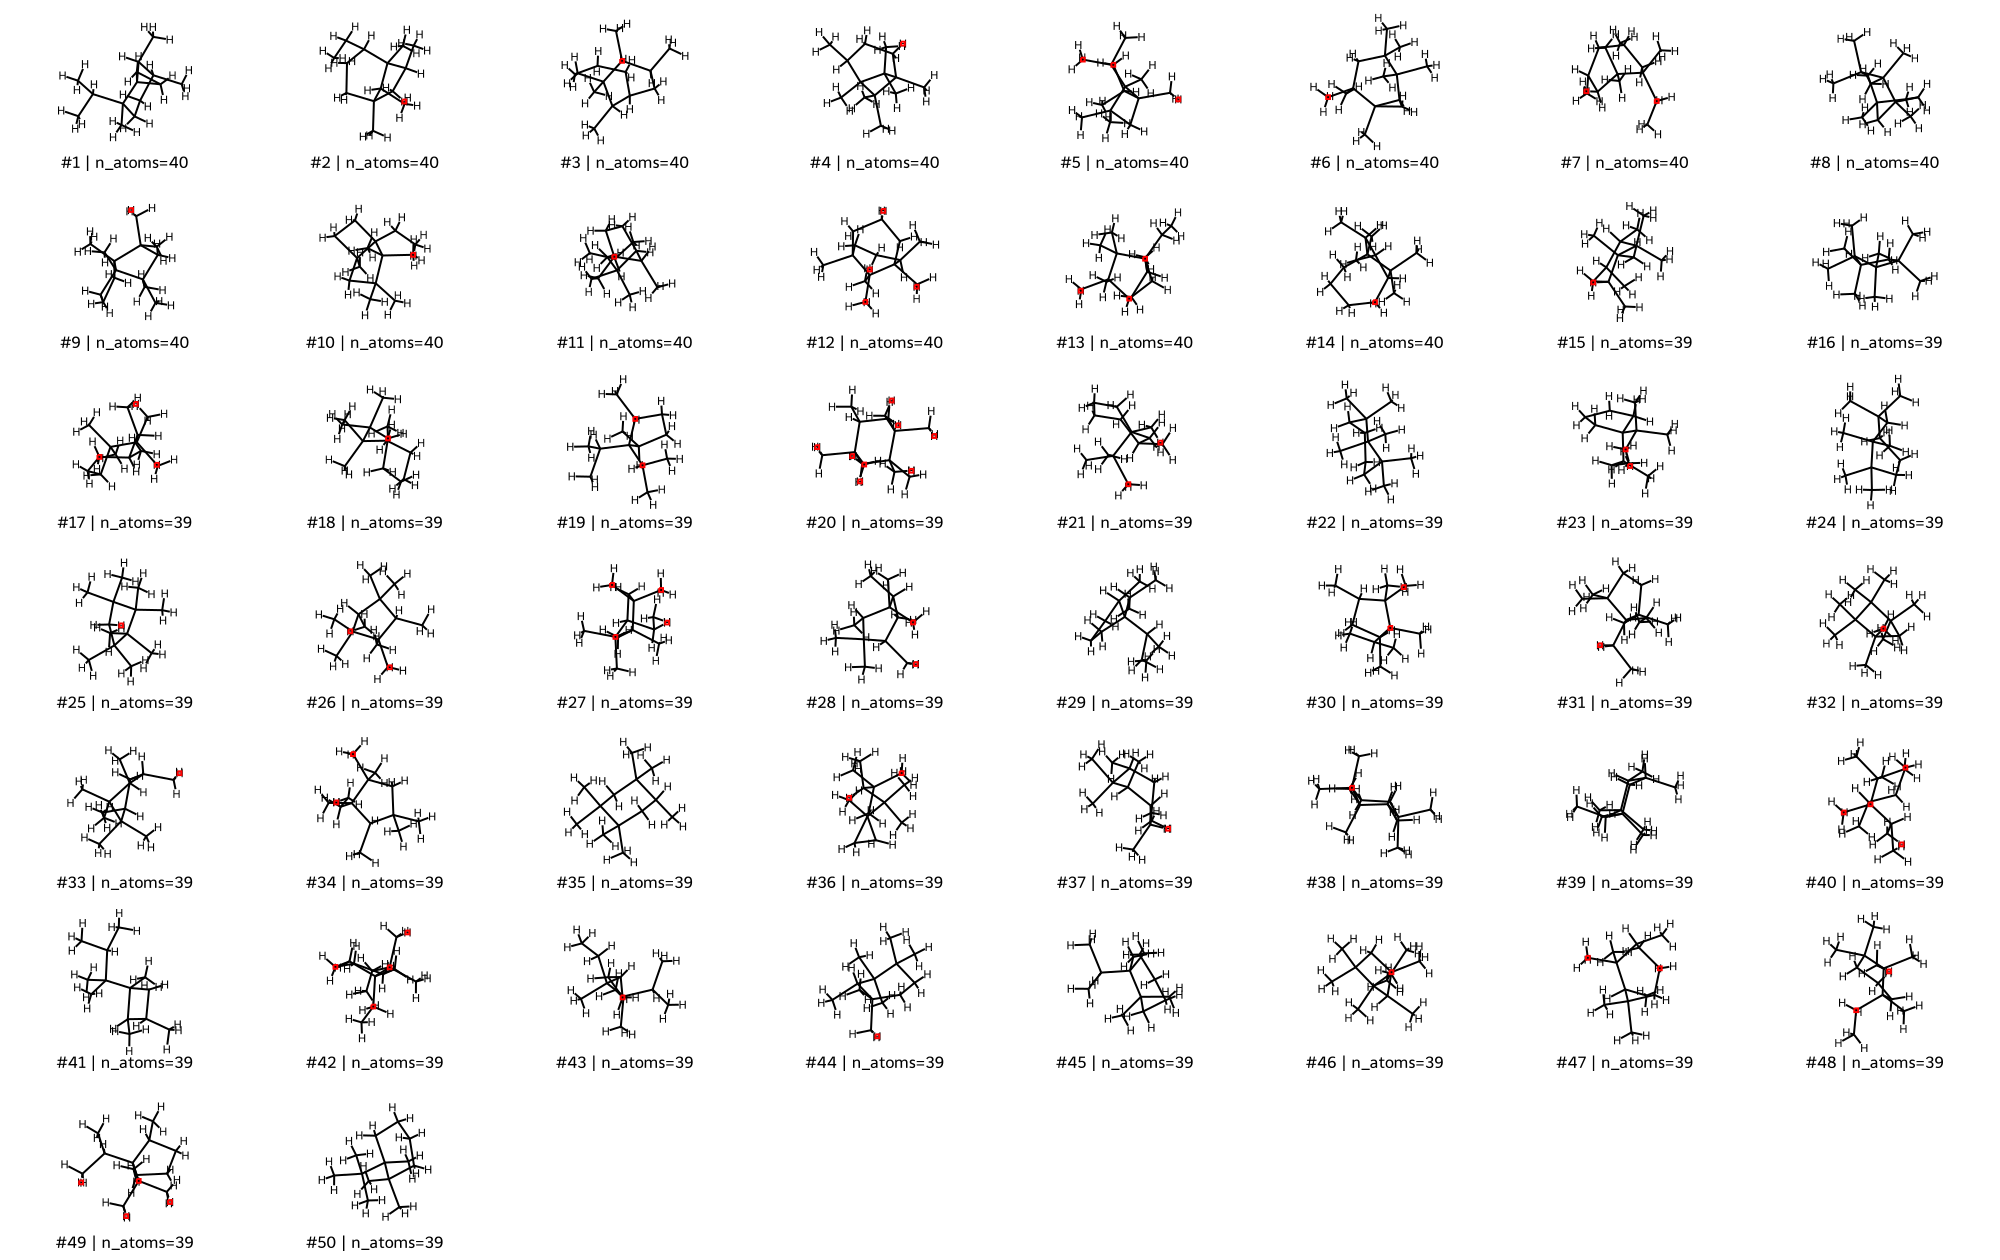

In [4]:
import hydra
from rl.eval_pretrained_validity import compose_cfg

# OmegaConf in our Hydra config uses ${oc.env:PROJECT_ROOT}.
os.environ.setdefault("PROJECT_ROOT", str(PROJECT_ROOT))

# We only need vocab for trajectory -> RDKit conversion.
# Instantiate preprocessing directly to avoid building the full model on CUDA.
cfg = compose_cfg(str(PROJECT_ROOT / "configs"), "default", overrides=blob.get("hydra_overrides", []))
preprocessing = hydra.utils.instantiate(cfg.data.preprocessing)
vocab = preprocessing.vocab


def final_mol_from_record(record, vocab):
    final_frame = record["trajectory"][-1]
    return final_frame.to_rdkit_mol(vocab.atom_tokens, vocab.edge_tokens, vocab.charge_tokens)


# Show molecules sorted by decreasing number of atoms.
# Tune this to render more/less molecules.
TOP_K = 64
MOLS_PER_ROW = 8
IMG_SIZE = (250, 180)

records_source = records_for_viz if "records_for_viz" in globals() else records
records_sorted = sorted(records_source, key=lambda r: int(r["final_n_atoms"]), reverse=True)
selected = records_sorted[:TOP_K]

mols = []
legends = []
for i, rec in enumerate(selected):
    mol = final_mol_from_record(rec, vocab)
    if mol is None:
        continue
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    mols.append(mol)
    legends.append(f"#{i+1} | n_atoms={int(rec['final_n_atoms'])}")

if not mols:
    print("No molecules could be rendered.")
else:
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=MOLS_PER_ROW,
        subImgSize=IMG_SIZE,
        legends=legends,
        useSVG=True,
    )
    display(img)

In [5]:
# Optional deduplication: keep one record per unique final molecule (canonical SMILES).
# Downstream cells use `records_for_viz` if present.
# Also summarizes generic Murcko scaffolds (RDKit GetScaffoldForMol + MakeScaffoldGeneric),
# matching rl/rewards.scaffold_diversity_wrapper defaults (generic_scaffold=True).

def generic_murcko_smiles(mol: Chem.Mol) -> str | None:
    """Same chemistry as rl/rewards._murcko_scaffold_smiles(..., generic=True)."""
    try:
        from rdkit.Chem.Scaffolds import MurckoScaffold

        core = MurckoScaffold.GetScaffoldForMol(mol)
        if core is None:
            return None
        try:
            MurckoScaffold.MakeScaffoldGeneric(core)
        except Exception:
            pass
        return Chem.MolToSmiles(core)
    except Exception:
        return None


dedup_by_final_smiles = True

parsed: list[dict] = []
skipped_convert = 0

for rec in records:
    mol = final_mol_from_record(rec, vocab)
    if mol is None:
        skipped_convert += 1
        continue
    try:
        smiles = Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        skipped_convert += 1
        continue
    scaffold = generic_murcko_smiles(mol)
    parsed.append({"record": rec, "smiles": smiles, "scaffold": scaffold})

n_parsed = len(parsed)
n_scaffold_fail = sum(1 for p in parsed if p["scaffold"] is None)
scaffold_ok = [p["scaffold"] for p in parsed if p["scaffold"] is not None]
n_unique_smi = len({p["smiles"] for p in parsed})
n_unique_scaf = len(set(scaffold_ok))

print("=== Generic Murcko — RDKit-convertible records only ===")
print(f"records_total: {len(records)}")
print(f"skipped_rdkit_or_canonical_smiles: {skipped_convert}")
print(f"parsed_molecules: {n_parsed}")
print(f"generic_murcko_extract_fail: {n_scaffold_fail}")
print(f"unique_canonical_smiles: {n_unique_smi}")
print(f"unique_generic_murcko: {n_unique_scaf}")
if n_unique_smi and n_unique_scaf:
    print(f"unique_smiles / unique_murcko: {n_unique_smi / n_unique_scaf:.3f}")
if scaffold_ok:
    ctr_all = Counter(scaffold_ok)
    print(f"molecules_per_scaffold_mean: {len(scaffold_ok) / len(ctr_all):.3f}")
    print("top_10_generic_scaffolds_by_count (among parsed):")
    for i, (sc, c) in enumerate(ctr_all.most_common(10), 1):
        short = sc if len(sc) <= 72 else sc[:69] + "..."
        print(f"  {i:>2}  count={c:<4}  {short}")

if not dedup_by_final_smiles:
    records_for_viz = list(records)
    print(f"\nDedup disabled: using all {len(records_for_viz)} records")
    print(
        "(Murcko block above is over RDKit-convertible rows only; "
        "includes duplicate SMILES if present.)"
    )
else:
    unique_by_smiles: dict[str, dict] = {}
    for p in parsed:
        smi = p["smiles"]
        if smi not in unique_by_smiles:
            unique_by_smiles[smi] = {
                "record": p["record"],
                "count": 1,
                "scaffold": p["scaffold"],
            }
        else:
            unique_by_smiles[smi]["count"] += 1

    dedup_items = sorted(
        unique_by_smiles.items(),
        key=lambda kv: int(kv[1]["record"]["final_n_atoms"]),
        reverse=True,
    )
    records_for_viz = [item[1]["record"] for item in dedup_items]
    duplicate_count = len(records) - len(records_for_viz)

    print(f"\nInput records: {len(records)}")
    print(f"Unique final molecules: {len(records_for_viz)}")
    print(f"Dropped duplicates (record rows − unique SMILES kept): {duplicate_count}")
    if skipped_convert:
        print(f"Skipped non-convertible records: {skipped_convert}")

    dedup_scafs = [v["scaffold"] for v in unique_by_smiles.values() if v["scaffold"] is not None]
    print("\n=== Generic Murcko — unique final molecules (deduped by SMILES) ===")
    print(f"unique_molecules: {len(unique_by_smiles)}")
    print(f"unique_generic_murcko: {len(set(dedup_scafs))}")
    if dedup_scafs:
        ctr_d = Counter(dedup_scafs)
        print(f"molecules_per_scaffold_mean: {len(dedup_scafs) / len(ctr_d):.3f}")
        print("top_10_generic_scaffolds_by_count (dedup set):")
        for i, (sc, c) in enumerate(ctr_d.most_common(10), 1):
            short = sc if len(sc) <= 72 else sc[:69] + "..."
            print(f"  {i:>2}  count={c:<4}  {short}")

=== Generic Murcko — RDKit-convertible records only ===
records_total: 294
skipped_rdkit_or_canonical_smiles: 0
parsed_molecules: 294
generic_murcko_extract_fail: 0
unique_canonical_smiles: 280
unique_generic_murcko: 88
unique_smiles / unique_murcko: 3.182
molecules_per_scaffold_mean: 3.341
top_10_generic_scaffolds_by_count (among parsed):
   1  count=33    C1CC2CCC(C1)C2
   2  count=25    C1CCCC1
   3  count=24    C1CCCCC1
   4  count=21    C1CC2CCC1C2
   5  count=12    C1CC2CCCC2C1
   6  count=8     C1CCCCCC1
   7  count=8     C1CCC2CCC2C1
   8  count=8     C1CC2CCCC(C1)C2
   9  count=7     C1CC2CCC(C1)CC2
  10  count=7     C1CCC2CCCC2C1

Input records: 294
Unique final molecules: 280
Dropped duplicates (record rows − unique SMILES kept): 14

=== Generic Murcko — unique final molecules (deduped by SMILES) ===
unique_molecules: 280
unique_generic_murcko: 88
molecules_per_scaffold_mean: 3.182
top_10_generic_scaffolds_by_count (dedup set):
   1  count=32    C1CC2CCC(C1)C2
   2  count=21

Trajectory #9: frames=200, final_n_atoms=40


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

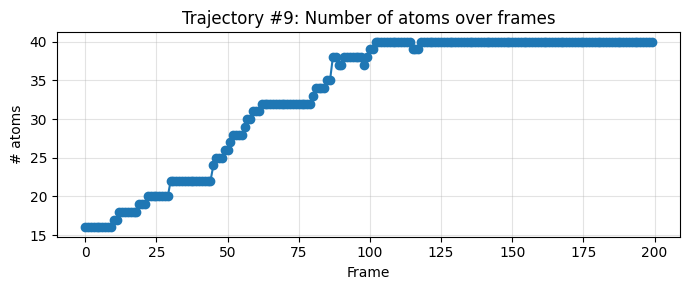

In [6]:
import matplotlib.pyplot as plt
from notebooks.utils import process_mol, visualize_variable_topology

# Pick which saved RL trajectory to inspect in 3D.
traj_idx = 9
ANIM_INTERVAL_MS = 20

records_source = records_for_viz if "records_for_viz" in globals() else records

if not records_source:
    print("No records available.")
elif traj_idx < 0 or traj_idx >= len(records_source):
    print(f"traj_idx={traj_idx} is out of range [0, {len(records_source) - 1}]")
else:
    rec = records_source[traj_idx]
    traj = rec["trajectory"]

    # Convert each frame into tokenized atom/edge dicts expected by visualize_variable_topology.
    traj_frames = [
        process_mol(frame, vocab.atom_tokens, vocab.charge_tokens, vocab.edge_tokens)
        for frame in traj
    ]

    print(
        f"Trajectory #{traj_idx}: frames={len(traj_frames)}, "
        f"final_n_atoms={int(rec.get('final_n_atoms', -1))}"
    )

    view = visualize_variable_topology(
        traj_frames,
        width=950,
        height=460,
        interval=ANIM_INTERVAL_MS,
    )
    view.show()

    num_atoms_per_frame = [len(frame["atoms"]) for frame in traj_frames]
    plt.figure(figsize=(7, 3))
    plt.plot(range(len(num_atoms_per_frame)), num_atoms_per_frame, marker="o", linewidth=1.5)
    plt.title(f"Trajectory #{traj_idx}: Number of atoms over frames")
    plt.xlabel("Frame")
    plt.ylabel("# atoms")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()